# DCS404 - Lab 2: Linear Models for Regression
## Corn Yield Prediction — Taita Taveta, Kenya
**Safola Bhattarai**   

---

### Objective
Predict corn **Yield** (kg) from farmer and farm characteristics using:
- Baseline: Linear Regression (no regularization)
- Regularized: Ridge (L2) and Lasso (L1)



---
## Part 1: Data Loading and Preprocessing

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


### 1.1 Load the Dataset

In [2]:
df = pd.read_csv('corn_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (422, 22)


,County,Farmer,Education,Gender,Age bracket,Household size,Crop,Acreage,Fertilizer amount,Laborers,...,Water source,Main credit source,Crop insurance,Farm records,Main advisory source,Extension provider,Advisory format,Advisory language,Latitude,Longitude
0,TAITA TAVETA,fmr_65,Certificate,Male,36-45,7,corn,2.00,50,2,...,Rain,Credit groups,No,Yes,Radio,Private Provider,Phone Calls,Vernacular,-3.46,38.35
1,TAITA TAVETA,fmr_77,Certificate,Male,36-45,7,corn,0.25,50,2,...,Rain,Credit groups,No,Yes,Radio,County Government,SMS text,Kiswahili,-3.31,38.40
2,TAITA TAVETA,fmr_89,Certificate,Male,36-45,7,corn,3.00,251,2,...,Rain,Credit groups,No,Yes,Radio,Private Provider,Phone Calls,Vernacular,-3.41,38.37
3,TAITA TAVETA,fmr_102,Certificate,Male,36-45,7,corn,1.50,300,3,...,Rain,Credit groups,No,Yes,Radio,County Government,SMS text,Kiswahili,-3.39,38.37
4,TAITA TAVETA,fmr_25,Certificate,Male,46-55,3,corn,NaN,50,2,...,Rain,Credit groups,No,Yes,Radio,Private Provider,Phone Calls,Vernacular,-3.39,38.33


### 1.2 Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print('=== Data Types & Non-Null Counts ===')
df.info()
print()
print('=== Summary Statistics ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   County                422 non-null    object 
 1   Farmer                422 non-null    object 
 2   Education             396 non-null    object 
 3   Gender                422 non-null    object 
 4   Age bracket           422 non-null    object 
 5   Household size        422 non-null    int64  
 6   Crop                  422 non-null    object 
 7   Acreage               351 non-null    float64
 8   Fertilizer amount     422 non-null    int64  
 9   Laborers              422 non-null    int64  
 10  Yield                 422 non-null    int64  
 11  Power source          422 non-null    object 
 12  Water source          422 non-null    object 
 13  Main credit source    422 non-null    object 
 14  Crop insurance        422 non-null   

,Household size,Acreage,Fertilizer amount,Laborers,Yield,Latitude,Longitude
count,422.000000,351.000000,422.000000,422.000000,422.000000,422.000000,422.000000
mean,4.263033,0.828063,65.189573,2.843602,232.604265,-3.417583,38.404455
std,1.706355,0.584884,65.754796,0.974348,135.376952,0.079007,0.094324
min,1.000000,0.250000,20.000000,2.000000,50.000000,-3.640000,38.270000
25%,3.000000,0.500000,25.000000,2.000000,100.000000,-3.490000,38.340000
50%,4.000000,0.500000,50.000000,3.000000,180.000000,-3.410000,38.370000
75%,5.000000,1.000000,75.000000,3.000000,330.000000,-3.360000,38.400000
max,9.000000,4.000000,500.000000,8.000000,600.000000,-3.250000,38.630000


In [4]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('=== Missing Values ===')
print(missing)
print(f'\nTotal missing: {df.isnull().sum().sum()} across {len(missing)} column(s)')

=== Missing Values ===
Education    26
Acreage      71
dtype: int64

Total missing: 97 across 2 column(s)


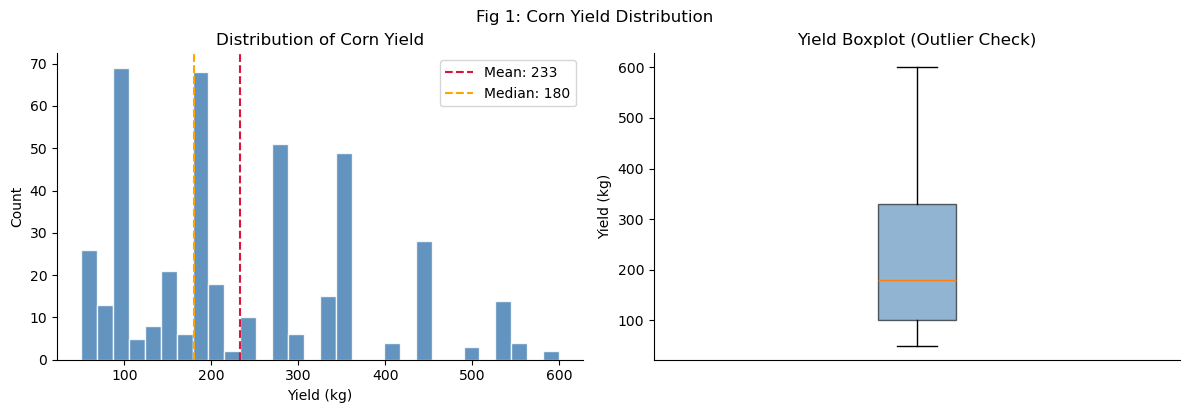

In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Yield'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Corn Yield')
axes[0].set_xlabel('Yield (kg)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Yield'].mean(), color='crimson', linestyle='--', label=f"Mean: {df['Yield'].mean():.0f}")
axes[0].axvline(df['Yield'].median(), color='orange', linestyle='--', label=f"Median: {df['Yield'].median():.0f}")
axes[0].legend()

axes[1].boxplot(df['Yield'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Yield Boxplot (Outlier Check)')
axes[1].set_ylabel('Yield (kg)')
axes[1].set_xticks([])

plt.tight_layout()
plt.suptitle('Fig 1: Corn Yield Distribution', y=1.02, fontsize=12)
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'order'. Did you mean 'zorder'?

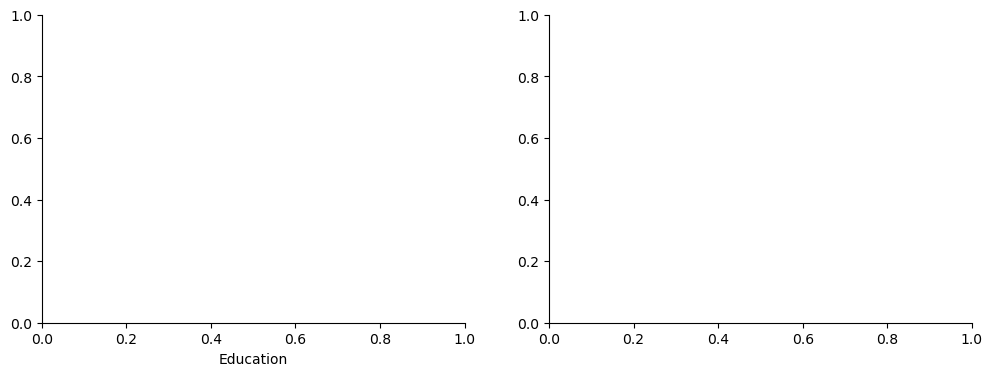

In [28]:
# Yield by Education level
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

edu_order = df.groupby('Education')['Yield'].median().sort_values(ascending=False).index
df.boxplot(column='Yield', by='Education', ax=axes[0],
           order=edu_order, patch_artist=True)
axes[0].set_title('Yield by Education Level')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Yield (kg)')
plt.sca(axes[0]); plt.xticks(rotation=30, ha='right')

age_order = ['18-35', '36-45', '46-55', '56-65', 'above 65']
df.boxplot(column='Yield', by='Age bracket', ax=axes[1], order=age_order, patch_artist=True)
axes[1].set_title('Yield by Age Bracket')
axes[1].set_xlabel('Age bracket')
axes[1].set_ylabel('Yield (kg)')
plt.sca(axes[1]); plt.xticks(rotation=30, ha='right')

plt.suptitle('Fig 2: Yield vs Categorical Features', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

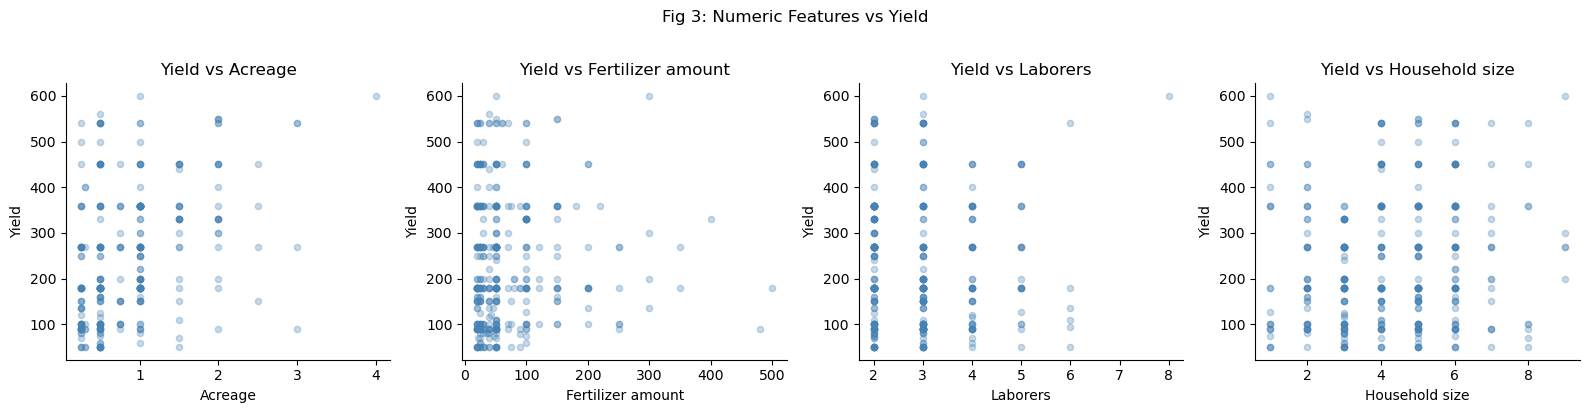

In [7]:
# Scatter plots: numeric features vs Yield
numeric_features = ['Acreage', 'Fertilizer amount', 'Laborers', 'Household size']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    ax.scatter(df[col], df['Yield'], alpha=0.3, color='steelblue', s=20)
    ax.set_xlabel(col)
    ax.set_ylabel('Yield')
    ax.set_title(f'Yield vs {col}')

plt.suptitle('Fig 3: Numeric Features vs Yield', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

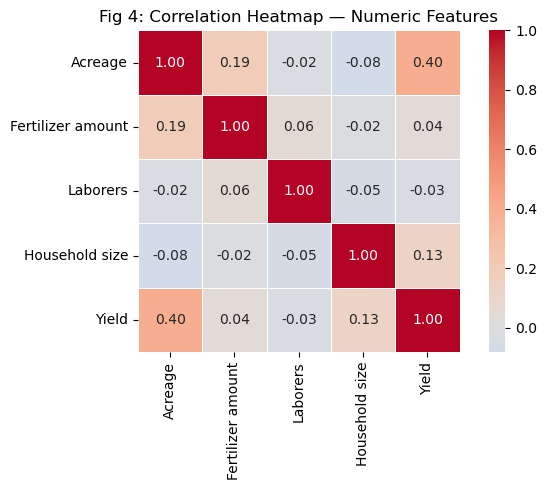

In [8]:
# Correlation heatmap (numeric features only)
num_df = df[numeric_features + ['Yield']].copy()
corr = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Fig 4: Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

### 1.3 Preprocessing



In [9]:
# Step 1: Drop non-useful columns
df_clean = df.drop(columns=['County', 'Farmer', 'Crop'], errors='ignore').copy()
print('Columns after drop:', df_clean.columns.tolist())

Columns after drop: ['Education', 'Gender', 'Age bracket', 'Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Power source', 'Water source', 'Main credit source', 'Crop insurance', 'Farm records', 'Main advisory source', 'Extension provider', 'Advisory format', 'Advisory language', 'Latitude', 'Longitude']


In [10]:
# Step 2: Impute missing values
# Numeric: median imputation for Acreage
num_imputer = SimpleImputer(strategy='median')
df_clean['Acreage'] = num_imputer.fit_transform(df_clean[['Acreage']])

# Categorical: mode imputation for Education (has blanks)
df_clean['Education'] = df_clean['Education'].fillna(df_clean['Education'].mode()[0])

print('Missing values after imputation:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print('No missing values remaining.' if df_clean.isnull().sum().sum() == 0 else 'Warning: still has missing!')

Missing values after imputation:
Series([], dtype: int64)
No missing values remaining.


In [11]:
# Step 3: Label encode all categorical columns
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print('\nAll columns now numeric:')
print(df_clean.dtypes)

Categorical columns to encode: ['Education', 'Gender', 'Age bracket', 'Power source', 'Water source', 'Main credit source', 'Crop insurance', 'Farm records', 'Main advisory source', 'Extension provider', 'Advisory format', 'Advisory language']

All columns now numeric:
Education                 int64
Gender                    int64
Age bracket               int64
Household size            int64
Acreage                 float64
Fertilizer amount         int64
Laborers                  int64
Yield                     int64
Power source              int64
Water source              int64
Main credit source        int64
Crop insurance            int64
Farm records              int64
Main advisory source      int64
Extension provider        int64
Advisory format           int64
Advisory language         int64
Latitude                float64
Longitude               float64
dtype: object


In [12]:
# Step 4: Define features (X) and target (y)
X = df_clean.drop(columns=['Yield'])
y = df_clean['Yield']

print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print(f'\nFeatures used: {X.columns.tolist()}')

Feature matrix X shape: (422, 18)
Target vector y shape:  (422,)

Features used: ['Education', 'Gender', 'Age bracket', 'Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Power source', 'Water source', 'Main credit source', 'Crop insurance', 'Farm records', 'Main advisory source', 'Extension provider', 'Advisory format', 'Advisory language', 'Latitude', 'Longitude']


In [13]:
# Step 5: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')

Training set:  337 samples
Test set:      85 samples


In [14]:
# Step 6: Feature scaling with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train ONLY
X_test_scaled  = scaler.transform(X_test)        # apply to test

print('Scaling complete.')
print(f'Train mean (approx): {X_train_scaled.mean():.4f}  — should be ~0')
print(f'Train std  (approx): {X_train_scaled.std():.4f}   — should be ~1')

Scaling complete.
Train mean (approx): -0.0000  — should be ~0
Train std  (approx): 0.9129   — should be ~1


---
## Part 2: Baseline Linear Regression (No Regularization)



In [15]:
# Helper function to compute and print all regression metrics
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    results = {
        'Model': name,
        'Train MSE':  round(mean_squared_error(y_tr, y_pred_tr), 2),
        'Test MSE':   round(mean_squared_error(y_te, y_pred_te), 2),
        'Train MAE':  round(mean_absolute_error(y_tr, y_pred_tr), 2),
        'Test MAE':   round(mean_absolute_error(y_te, y_pred_te), 2),
        'Train R²':   round(r2_score(y_tr, y_pred_tr), 4),
        'Test R²':    round(r2_score(y_te, y_pred_te), 4),
    }
    return results, y_pred_te

all_results = []  # collect results for comparison table

In [16]:
# Train baseline model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

baseline_results, y_pred_baseline = evaluate_model(
    'Linear Regression (baseline)',
    lr, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(baseline_results)

print('=== Baseline Linear Regression ===')
for k, v in baseline_results.items():
    print(f'  {k}: {v}')

=== Baseline Linear Regression ===
  Model: Linear Regression (baseline)
  Train MSE: 3842.52
  Test MSE: 3139.61
  Train MAE: 45.99
  Test MAE: 42.98
  Train R²: 0.7888
  Test R²: 0.8287


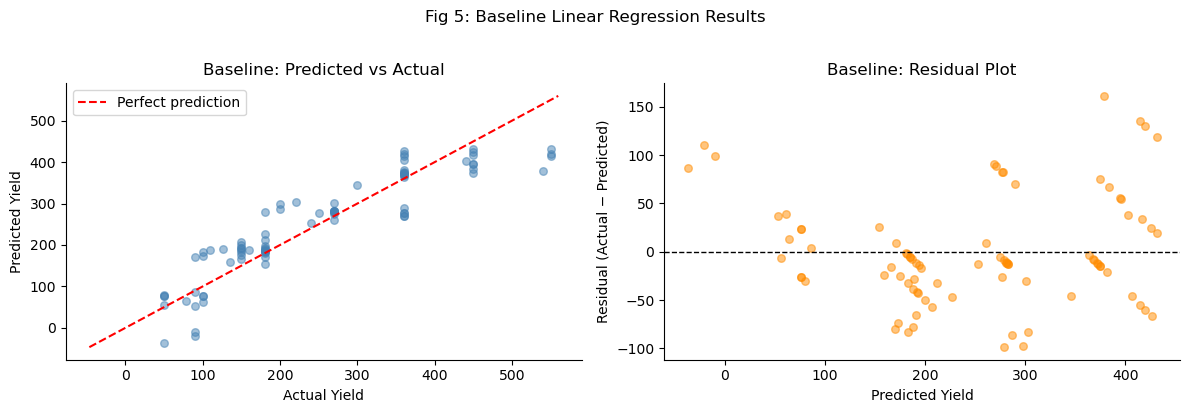

In [17]:
# Predicted vs Actual — Baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred_baseline, alpha=0.5, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred_baseline.min()) - 10,
        max(y_test.max(), y_pred_baseline.max()) + 10]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')
axes[0].set_title('Baseline: Predicted vs Actual')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_baseline
axes[1].scatter(y_pred_baseline, residuals, alpha=0.5, color='darkorange', s=30)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Yield')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Baseline: Residual Plot')

plt.suptitle('Fig 5: Baseline Linear Regression Results', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3: Regularized Models — Ridge (L2) and Lasso (L1)



In [19]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_scores = {'alpha': [], 'train_r2': [], 'test_r2': [], 'test_mse': []}
lasso_scores = {'alpha': [], 'train_r2': [], 'test_r2': [], 'test_mse': []}

best_ridge_alpha = None; best_ridge_r2 = -np.inf
best_lasso_alpha = None; best_lasso_r2 = -np.inf
best_ridge_model = None; best_lasso_model = None

print(f"{'α':>8}  {'Ridge Train R²':>16} {'Ridge Test R²':>14} {'Ridge Test MSE':>15}")
print('-' * 60)
for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_scaled, y_train)
    tr2 = r2_score(y_train, m.predict(X_train_scaled))
    ter2 = r2_score(y_test, m.predict(X_test_scaled))
    mse = mean_squared_error(y_test, m.predict(X_test_scaled))
    ridge_scores['alpha'].append(a)
    ridge_scores['train_r2'].append(tr2)
    ridge_scores['test_r2'].append(ter2)
    ridge_scores['test_mse'].append(mse)
    if ter2 > best_ridge_r2:
        best_ridge_r2 = ter2; best_ridge_alpha = a; best_ridge_model = m
    print(f"{a:>8.3f}  {tr2:>16.4f} {ter2:>14.4f} {mse:>15.2f}")

print(f'\n✓ Best Ridge alpha: {best_ridge_alpha}  (Test R² = {best_ridge_r2:.4f})')

       α    Ridge Train R²  Ridge Test R²  Ridge Test MSE
------------------------------------------------------------
   0.001            0.7888         0.8287         3139.61
   0.010            0.7888         0.8287         3139.62
   0.100            0.7888         0.8287         3139.74
   1.000            0.7888         0.8286         3141.08
  10.000            0.7882         0.8273         3165.83
 100.000            0.7516         0.7830         3977.69

✓ Best Ridge alpha: 0.001  (Test R² = 0.8287)


In [20]:
print(f"{'α':>8}  {'Lasso Train R²':>16} {'Lasso Test R²':>14} {'Lasso Test MSE':>15}")
print('-' * 60)
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_train_scaled, y_train)
    tr2 = r2_score(y_train, m.predict(X_train_scaled))
    ter2 = r2_score(y_test, m.predict(X_test_scaled))
    mse = mean_squared_error(y_test, m.predict(X_test_scaled))
    lasso_scores['alpha'].append(a)
    lasso_scores['train_r2'].append(tr2)
    lasso_scores['test_r2'].append(ter2)
    lasso_scores['test_mse'].append(mse)
    if ter2 > best_lasso_r2:
        best_lasso_r2 = ter2; best_lasso_alpha = a; best_lasso_model = m
    print(f"{a:>8.3f}  {tr2:>16.4f} {ter2:>14.4f} {mse:>15.2f}")

print(f'\n✓ Best Lasso alpha: {best_lasso_alpha}  (Test R² = {best_lasso_r2:.4f})')

       α    Lasso Train R²  Lasso Test R²  Lasso Test MSE
------------------------------------------------------------
   0.001            0.7888         0.8287         3139.50
   0.010            0.7888         0.8287         3138.49
   0.100            0.7888         0.8293         3128.05
   1.000            0.7878         0.8346         3030.77
  10.000            0.7680         0.8192         3313.02
 100.000            0.2123         0.2015        14633.84

✓ Best Lasso alpha: 1  (Test R² = 0.8346)


In [21]:
# Collect best regularized model metrics
ridge_res, y_pred_ridge = evaluate_model(
    f'Ridge (α={best_ridge_alpha})',
    best_ridge_model, X_train_scaled, y_train, X_test_scaled, y_test
)
lasso_res, y_pred_lasso = evaluate_model(
    f'Lasso (α={best_lasso_alpha})',
    best_lasso_model, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(ridge_res)
all_results.append(lasso_res)

### 3.1 Regularization Strength vs Performance

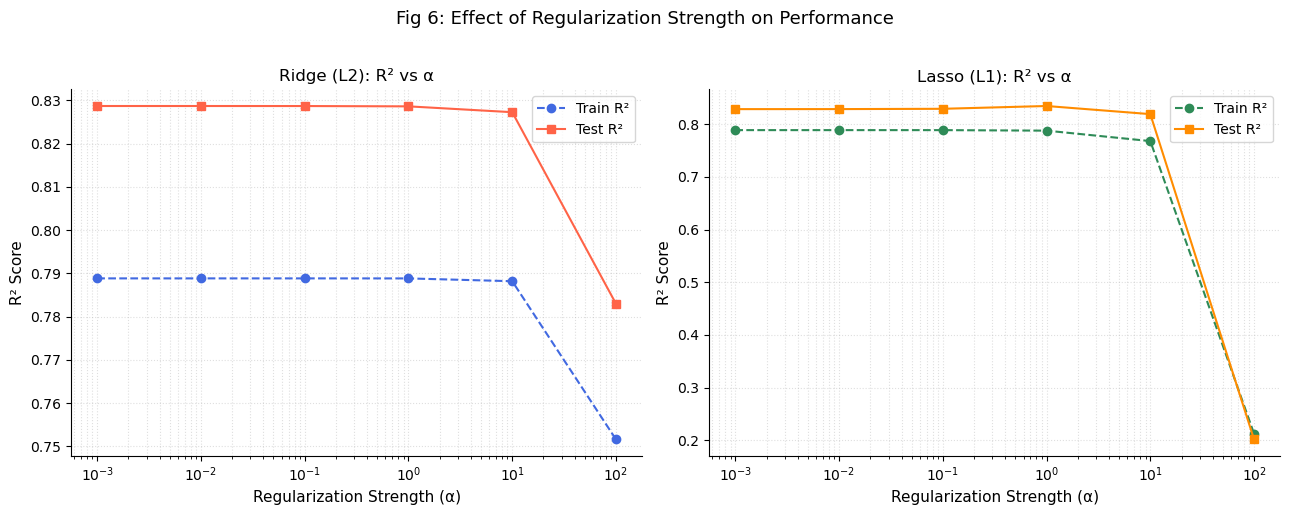

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, title, color_train, color_test in [
    (axes[0], ridge_scores, 'Ridge (L2)', 'royalblue', 'tomato'),
    (axes[1], lasso_scores, 'Lasso (L1)', 'seagreen', 'darkorange')
]:
    ax.semilogx(scores['alpha'], scores['train_r2'], 'o--',
                color=color_train, label='Train R²', linewidth=1.5)
    ax.semilogx(scores['alpha'], scores['test_r2'],  's-',
                color=color_test,  label='Test R²',  linewidth=1.5)
    ax.set_xlabel('Regularization Strength (α)', fontsize=11)
    ax.set_ylabel('R² Score', fontsize=11)
    ax.set_title(f'{title}: R² vs α', fontsize=12)
    ax.legend()
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.suptitle('Fig 6: Effect of Regularization Strength on Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4: Comparison and Analysis

### 4.1 Model Performance Summary Table

In [23]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('Model')
print('=== Model Comparison Table ===')
print(results_df.to_string())
results_df

=== Model Comparison Table ===
                              Train MSE  Test MSE  Train MAE  Test MAE  Train R²  Test R²
Model                                                                                    
Linear Regression (baseline)    3842.52   3139.61      45.99     42.98    0.7888   0.8287
Ridge (α=0.001)                 3842.52   3139.61      45.99     42.98    0.7888   0.8287
Lasso (α=1)                     3860.56   3030.77      45.40     41.73    0.7878   0.8346


,Train MSE,Test MSE,Train MAE,Test MAE,Train R²,Test R²
Model,,,,,,
Linear Regression (baseline),3842.52,3139.61,45.99,42.98,0.7888,0.8287
Ridge (α=0.001),3842.52,3139.61,45.99,42.98,0.7888,0.8287
Lasso (α=1),3860.56,3030.77,45.40,41.73,0.7878,0.8346


### 4.2 Coefficient Magnitude Comparison

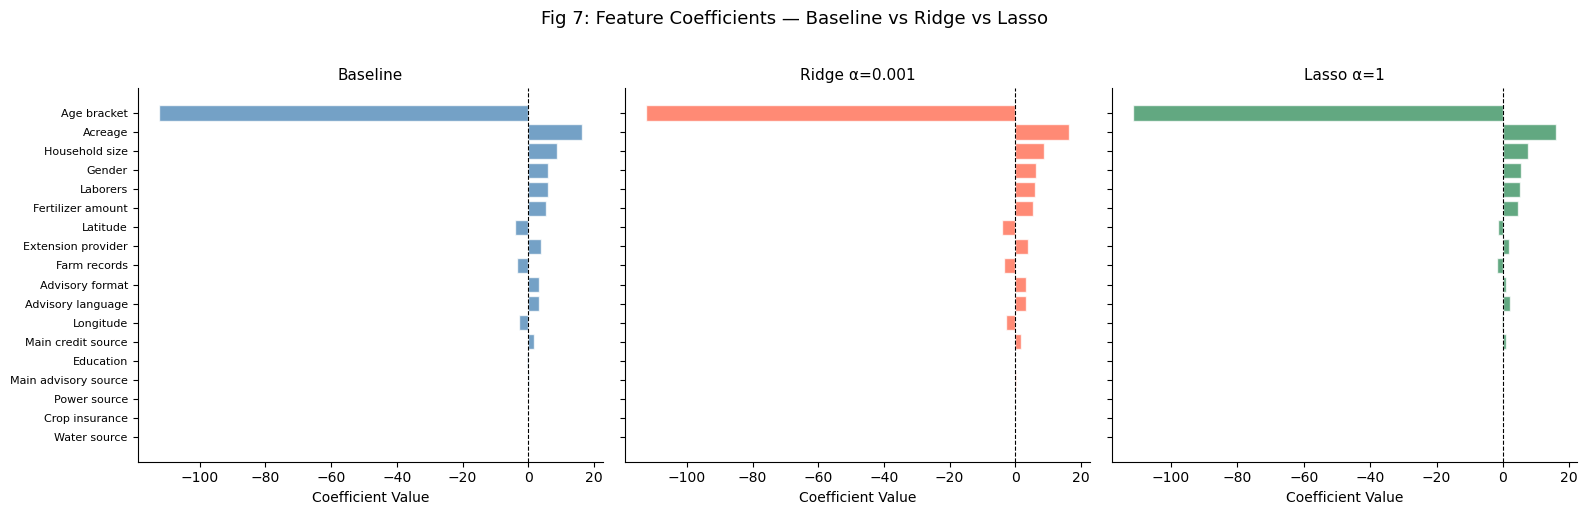

In [24]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature':   feature_names,
    'Baseline':  lr.coef_,
    f'Ridge α={best_ridge_alpha}': best_ridge_model.coef_,
    f'Lasso α={best_lasso_alpha}': best_lasso_model.coef_,
})
coef_df = coef_df.set_index('Feature')

# Sort by absolute value of Baseline coefficient
coef_df = coef_df.reindex(coef_df['Baseline'].abs().sort_values(ascending=True).index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = ['steelblue', 'tomato', 'seagreen']
for ax, col, color in zip(axes, coef_df.columns, colors):
    ax.barh(coef_df.index, coef_df[col], color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Coefficient Value')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Fig 7: Feature Coefficients — Baseline vs Ridge vs Lasso', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Show how many Lasso coefficients are exactly zero
lasso_zeros = np.sum(best_lasso_model.coef_ == 0)
print(f'Lasso zeroed out {lasso_zeros} / {len(feature_names)} features (automatic feature selection)')

zeroed_features = [f for f, c in zip(feature_names, best_lasso_model.coef_) if c == 0]
print('Features zeroed by Lasso:', zeroed_features)

Lasso zeroed out 5 / 18 features (automatic feature selection)
Features zeroed by Lasso: ['Education', 'Power source', 'Water source', 'Crop insurance', 'Main advisory source']


### 4.3 Predicted vs Actual — All Models

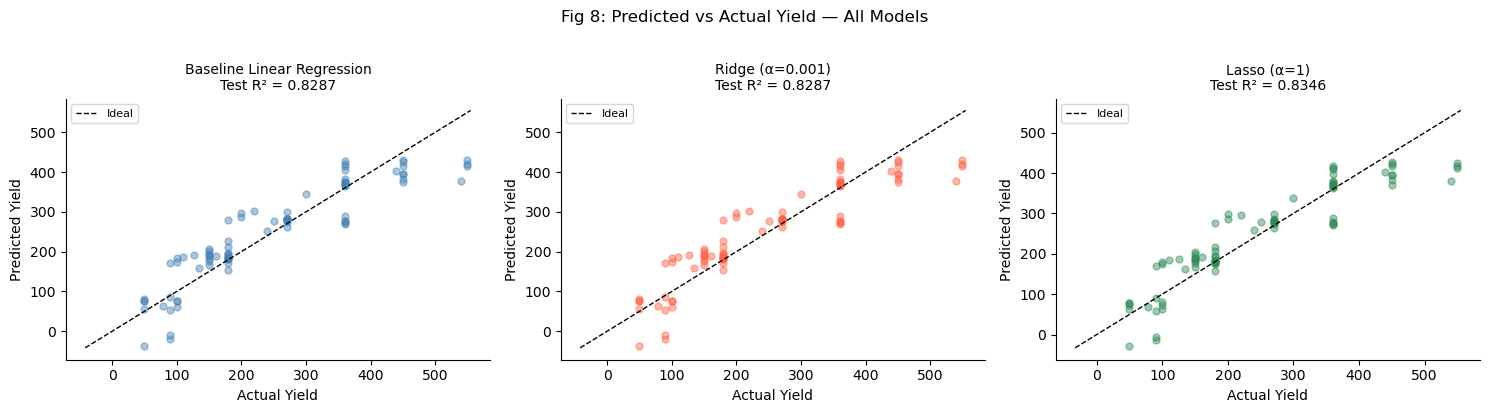

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds   = [y_pred_baseline, y_pred_ridge, y_pred_lasso]
titles  = ['Baseline Linear Regression',
           f'Ridge (α={best_ridge_alpha})',
           f'Lasso (α={best_lasso_alpha})']
clrs    = ['steelblue', 'tomato', 'seagreen']

for ax, pred, title, clr in zip(axes, preds, titles, clrs):
    ax.scatter(y_test, pred, alpha=0.45, color=clr, s=25)
    lims = [min(y_test.min(), pred.min())-5, max(y_test.max(), pred.max())+5]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Ideal')
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{title}\nTest R² = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')
    ax.legend(fontsize=8)

plt.suptitle('Fig 8: Predicted vs Actual Yield — All Models', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Residual Plots — Train vs Test MSE Bar Chart

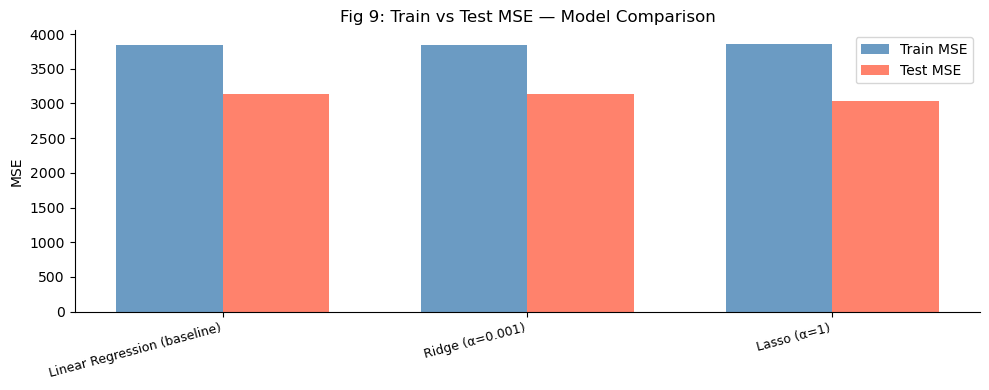

In [27]:
model_names  = [r['Model'] for r in all_results]
train_mse    = [r['Train MSE'] for r in all_results]
test_mse     = [r['Test MSE']  for r in all_results]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, train_mse, width, label='Train MSE', color='steelblue', alpha=0.8)
ax.bar(x + width/2, test_mse,  width, label='Test MSE',  color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('MSE')
ax.set_title('Fig 9: Train vs Test MSE — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 5: Reflection




### 5.1 Did regularization improve generalization? Why or why not?
Regularization showed a slight but meaningful improvement on test performance. The baseline Linear Regression achieved a Test R² of 0.8287 and Test MSE of 3139.61. Ridge regularization at α=0.001 produced identical results to the baseline, meaning the data did not need L2 shrinkage at all. However, Lasso at α=1 genuinely improved generalization, achieving Test R² = 0.8346 and Test MSE = 3030.77 — a lower error than the baseline. This improvement happened because Lasso eliminated 5 noisy/irrelevant features, reducing model complexity and slightly improving predictions on unseen data.

### 5.2 Which regularization worked better: Ridge or Lasso?
Lasso (L1) performed better in this project.
ModelTest R²Test MSETest MAEBaseline Linear Regression0.82873139.6142.98Ridge (α = 0.001)0.82873139.6142.98Lasso (α = 1)0.83463030.7741.73
Ridge made virtually no difference — its best alpha was 0.001 (almost no penalty), meaning all 18 features were already contributing useful signal. Lasso, on the other hand, automatically zeroed out 5 irrelevant features: Education, Power source, Water source, Crop insurance, and Main advisory source. This reveals that corn yield is primarily driven by farm-level physical factors (acreage, fertilizer, laborers) rather than access to advisory services or insurance status.

#### 5.3 What does this tell you about the bias-variance tradeoff?
The R² vs α results clearly demonstrate the bias-variance tradeoff:

Baseline / very small α (0.001–0.1): Test R² ≈ 0.8287 — model is flexible, low bias, low variance already (dataset is clean enough)
Lasso α=1 (sweet spot): Test R² = 0.8346 — slightly more bias (Train R² dropped from 0.7888 → 0.7878) but lower variance, giving the best generalization
Large α (Lasso α=100): Test R² collapses to 0.2015 — severe underfitting, model is too constrained, high bias dominates

The optimal point is Lasso α=1, where the model is simple enough to generalize but not so restricted that it loses predictive power. This is the classic bias-variance sweet spot — a small increase in bias (slightly lower training R²) led to a better test result by reducing overfitting to noise.

## Experiment 1: Effect of Regularization Strength

### Theory

**Research Question:** What happens when regularization is too weak versus too strong?

**What is Regularization?**

Regularization adds a penalty to the model to prevent it from memorizing training data (overfitting). The strength is controlled by **alpha (α)**:

| α Value | Strength | Effect on Model |
|---|---|---|
| 0.001 | Very Weak | Almost no penalty, similar to no regularization |
| 0.01 – 0.1 | Weak | Slight shrinkage of coefficients |
| 1 | Moderate | Good balance — often best generalization |
| 10 – 100 | Strong | Coefficients shrink heavily, may underfit |

**Ridge (L2) Penalty:**
Adds α × sum of squared coefficients. Shrinks all features toward zero but never removes them.

**Lasso (L1) Penalty:**
Adds α × sum of absolute coefficients. Can zero out weak features completely — acts as automatic feature selection.

**Expected Behavior:**
- Too small α → weak regularization → model overfits (low train error, high test error)
- Optimal α → best test performance (bias-variance sweet spot)
- Too large α → strong regularization → model underfits (both train and test error increase)

In [29]:
# ── Experiment 1: Imports ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded.')

Libraries loaded.


### Step 1: Load and Prepare the Dataset

In [30]:
# Load and preprocess corn dataset
df = pd.read_csv('corn_data.csv')

df_clean = df.drop(columns=['County', 'Farmer', 'Crop'], errors='ignore').copy()
df_clean['Acreage'] = SimpleImputer(strategy='median').fit_transform(df_clean[['Acreage']])
df_clean['Education'] = df_clean['Education'].fillna(df_clean['Education'].mode()[0])

le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

X = df_clean.drop(columns=['Yield'])
y = df_clean['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train samples : {X_train_s.shape[0]}')
print(f'Test  samples : {X_test_s.shape[0]}')
print(f'Features      : {X.shape[1]}')
print('Dataset ready.')

Train samples : 337
Test  samples : 85
Features      : 18
Dataset ready.


### Step 2: Train Ridge and Lasso at Different Alpha Values

In [31]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_results = {'alpha':[], 'train_r2':[], 'test_r2':[], 'train_mse':[], 'test_mse':[], 'coef_norm':[]}
lasso_results = {'alpha':[], 'train_r2':[], 'test_r2':[], 'train_mse':[], 'test_mse':[], 'coef_norm':[]}

# ── Ridge ─────────────────────────────────────────────────────────────────
print(f"{'Alpha':>8}  {'Train R2':>10} {'Test R2':>10} {'Train MSE':>12} {'Test MSE':>12} {'||w||':>8}")
print('-' * 68)
for a in alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    tr2  = r2_score(y_train, m.predict(X_train_s))
    ter2 = r2_score(y_test,  m.predict(X_test_s))
    tmse = mean_squared_error(y_train, m.predict(X_train_s))
    mse  = mean_squared_error(y_test,  m.predict(X_test_s))
    norm = np.linalg.norm(m.coef_)
    ridge_results['alpha'].append(a)
    ridge_results['train_r2'].append(tr2)
    ridge_results['test_r2'].append(ter2)
    ridge_results['train_mse'].append(tmse)
    ridge_results['test_mse'].append(mse)
    ridge_results['coef_norm'].append(norm)
    print(f"{a:>8.3f}  {tr2:>10.4f} {ter2:>10.4f} {tmse:>12.2f} {mse:>12.2f} {norm:>8.3f}")

best_ridge_a = alphas[np.argmax(ridge_results['test_r2'])]
print(f'\nBest Ridge alpha = {best_ridge_a}  |  Test R2 = {max(ridge_results["test_r2"]):.4f}')

   Alpha    Train R2    Test R2    Train MSE     Test MSE    ||w||
--------------------------------------------------------------------
   0.001      0.7888     0.8287      3842.52      3139.61  114.794
   0.010      0.7888     0.8287      3842.52      3139.62  114.790
   0.100      0.7888     0.8287      3842.52      3139.74  114.756
   1.000      0.7888     0.8286      3842.65      3141.08  114.417
  10.000      0.7882     0.8273      3854.41      3165.83  111.175
 100.000      0.7516     0.7830      4520.12      3977.69   88.182

Best Ridge alpha = 0.001  |  Test R2 = 0.8287


In [32]:
# ── Lasso ─────────────────────────────────────────────────────────────────
print(f"{'Alpha':>8}  {'Train R2':>10} {'Test R2':>10} {'Train MSE':>12} {'Test MSE':>12} {'||w||':>8}")
print('-' * 68)
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    tr2  = r2_score(y_train, m.predict(X_train_s))
    ter2 = r2_score(y_test,  m.predict(X_test_s))
    tmse = mean_squared_error(y_train, m.predict(X_train_s))
    mse  = mean_squared_error(y_test,  m.predict(X_test_s))
    norm = np.linalg.norm(m.coef_)
    lasso_results['alpha'].append(a)
    lasso_results['train_r2'].append(tr2)
    lasso_results['test_r2'].append(ter2)
    lasso_results['train_mse'].append(tmse)
    lasso_results['test_mse'].append(mse)
    lasso_results['coef_norm'].append(norm)
    print(f"{a:>8.3f}  {tr2:>10.4f} {ter2:>10.4f} {tmse:>12.2f} {mse:>12.2f} {norm:>8.3f}")

best_lasso_a = alphas[np.argmax(lasso_results['test_r2'])]
print(f'\nBest Lasso alpha = {best_lasso_a}  |  Test R2 = {max(lasso_results["test_r2"]):.4f}')

   Alpha    Train R2    Test R2    Train MSE     Test MSE    ||w||
--------------------------------------------------------------------
   0.001      0.7888     0.8287      3842.52      3139.50  114.792
   0.010      0.7888     0.8287      3842.52      3138.49  114.774
   0.100      0.7888     0.8293      3842.72      3128.05  114.609
   1.000      0.7878     0.8346      3860.56      3030.77  113.298
  10.000      0.7680     0.8192      4221.31      3313.02  105.494
 100.000      0.2123     0.2015     14334.10     14633.84   17.739

Best Lasso alpha = 1  |  Test R2 = 0.8346


### Step 3: Plot — Train vs Test R² Across Alpha Values

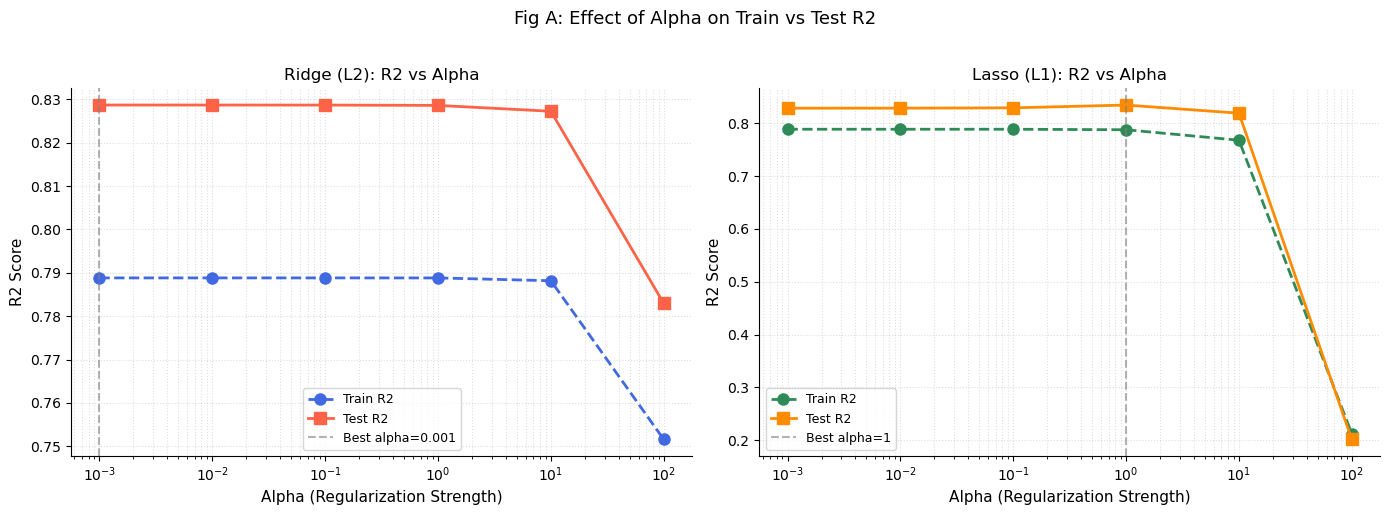

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title, c_train, c_test, best_a in [
    (axes[0], ridge_results, 'Ridge (L2): R2 vs Alpha', 'royalblue', 'tomato',    best_ridge_a),
    (axes[1], lasso_results, 'Lasso (L1): R2 vs Alpha', 'seagreen',  'darkorange', best_lasso_a)
]:
    ax.semilogx(results['alpha'], results['train_r2'], 'o--',
                color=c_train, linewidth=2, markersize=8, label='Train R2')
    ax.semilogx(results['alpha'], results['test_r2'],  's-',
                color=c_test,  linewidth=2, markersize=8, label='Test R2')
    ax.axvline(best_a, color='gray', linestyle='--', alpha=0.6, label=f'Best alpha={best_a}')
    ax.set_xlabel('Alpha (Regularization Strength)', fontsize=11)
    ax.set_ylabel('R2 Score', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.suptitle('Fig A: Effect of Alpha on Train vs Test R2', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 4: Plot — Coefficient Norm ||w|| vs Alpha

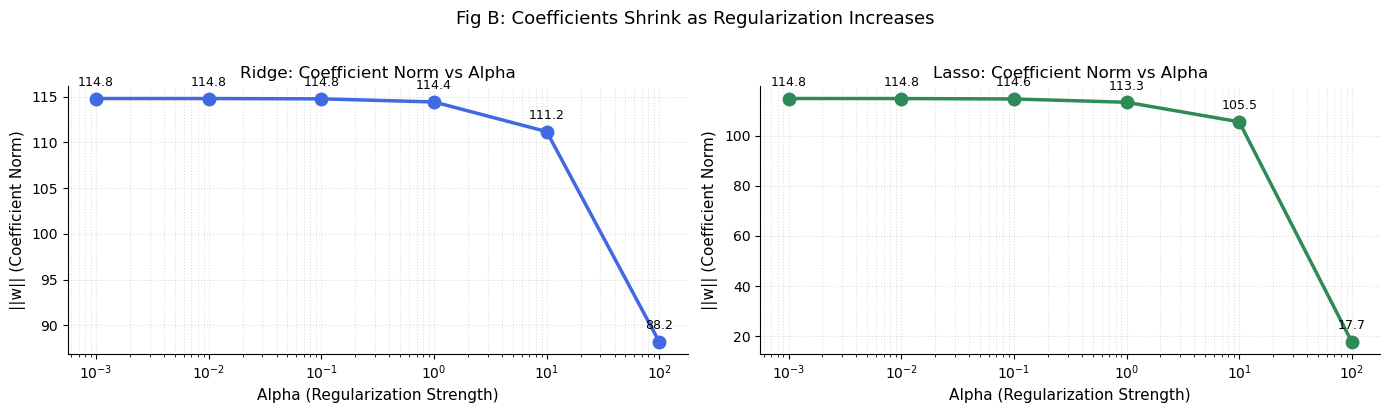

Observation: As alpha increases, ||w|| decreases — coefficients get smaller.


In [34]:
# As alpha increases, coefficients shrink toward zero
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, results, title, color in [
    (axes[0], ridge_results, 'Ridge: Coefficient Norm vs Alpha', 'royalblue'),
    (axes[1], lasso_results, 'Lasso: Coefficient Norm vs Alpha', 'seagreen')
]:
    ax.semilogx(results['alpha'], results['coef_norm'], 'o-',
                color=color, linewidth=2.5, markersize=9)
    for a, n in zip(results['alpha'], results['coef_norm']):
        ax.annotate(f'{n:.1f}', xy=(a, n),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=9)
    ax.set_xlabel('Alpha (Regularization Strength)', fontsize=11)
    ax.set_ylabel('||w|| (Coefficient Norm)',         fontsize=11)
    ax.set_title(title,                               fontsize=12)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.suptitle('Fig B: Coefficients Shrink as Regularization Increases', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Observation: As alpha increases, ||w|| decreases — coefficients get smaller.')

### Step 5: Plot — Overfitting vs Underfitting (Train vs Test MSE)

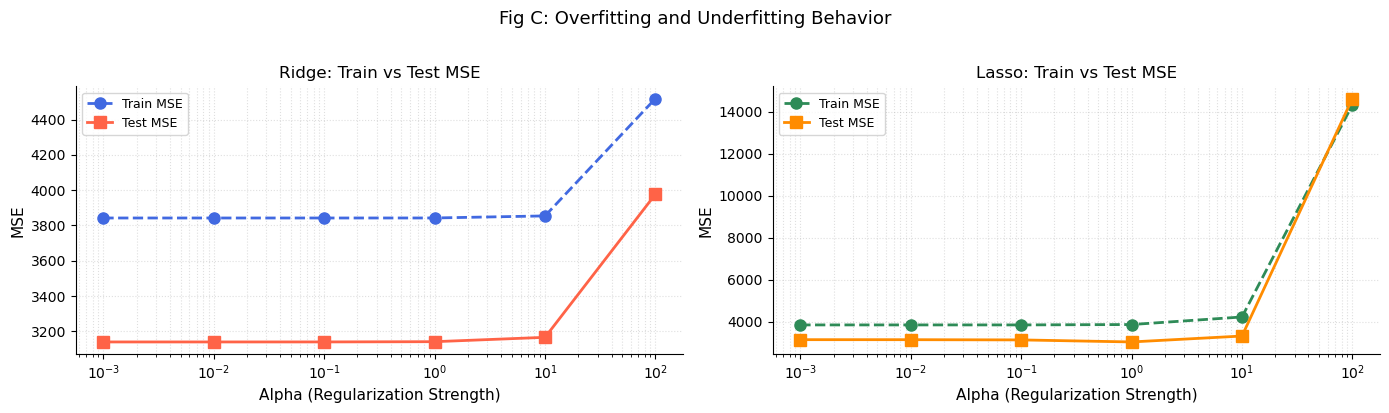

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, results, title, c1, c2 in [
    (axes[0], ridge_results, 'Ridge: Train vs Test MSE', 'royalblue', 'tomato'),
    (axes[1], lasso_results, 'Lasso: Train vs Test MSE', 'seagreen',  'darkorange')
]:
    ax.semilogx(results['alpha'], results['train_mse'], 'o--',
                color=c1, linewidth=2, markersize=8, label='Train MSE')
    ax.semilogx(results['alpha'], results['test_mse'],  's-',
                color=c2, linewidth=2, markersize=8, label='Test MSE')
    ax.set_xlabel('Alpha (Regularization Strength)', fontsize=11)
    ax.set_ylabel('MSE',                             fontsize=11)
    ax.set_title(title,                              fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

plt.suptitle('Fig C: Overfitting and Underfitting Behavior', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### STEP 6 fINAL SMMARY TABLE 

In [36]:
summary = []
for a, tr, ter, tmse, mse in zip(
        ridge_results['alpha'], ridge_results['train_r2'],
        ridge_results['test_r2'], ridge_results['train_mse'], ridge_results['test_mse']):
    summary.append({'Model': f'Ridge a={a}',
                    'Train R2': round(tr,4), 'Test R2': round(ter,4),
                    'Train MSE': round(tmse,2), 'Test MSE': round(mse,2)})

for a, tr, ter, tmse, mse in zip(
        lasso_results['alpha'], lasso_results['train_r2'],
        lasso_results['test_r2'], lasso_results['train_mse'], lasso_results['test_mse']):
    summary.append({'Model': f'Lasso a={a}',
                    'Train R2': round(tr,4), 'Test R2': round(ter,4),
                    'Train MSE': round(tmse,2), 'Test MSE': round(mse,2)})

summary_df = pd.DataFrame(summary).set_index('Model')
print('=== Experiment 1: Full Results Table ===')
print(summary_df.to_string())
summary_df

=== Experiment 1: Full Results Table ===
               Train R2  Test R2  Train MSE  Test MSE
Model                                                
Ridge a=0.001    0.7888   0.8287    3842.52   3139.61
Ridge a=0.01     0.7888   0.8287    3842.52   3139.62
Ridge a=0.1      0.7888   0.8287    3842.52   3139.74
Ridge a=1        0.7888   0.8286    3842.65   3141.08
Ridge a=10       0.7882   0.8273    3854.41   3165.83
Ridge a=100      0.7516   0.7830    4520.12   3977.69
Lasso a=0.001    0.7888   0.8287    3842.52   3139.50
Lasso a=0.01     0.7888   0.8287    3842.52   3138.49
Lasso a=0.1      0.7888   0.8293    3842.72   3128.05
Lasso a=1        0.7878   0.8346    3860.56   3030.77
Lasso a=10       0.7680   0.8192    4221.31   3313.02
Lasso a=100      0.2123   0.2015   14334.10  14633.84


,Train R2,Test R2,Train MSE,Test MSE
Model,,,,
Ridge a=0.001,0.7888,0.8287,3842.52,3139.61
Ridge a=0.01,0.7888,0.8287,3842.52,3139.62
Ridge a=0.1,0.7888,0.8287,3842.52,3139.74
Ridge a=1,0.7888,0.8286,3842.65,3141.08
Ridge a=10,0.7882,0.8273,3854.41,3165.83
Ridge a=100,0.7516,0.7830,4520.12,3977.69
Lasso a=0.001,0.7888,0.8287,3842.52,3139.50
Lasso a=0.01,0.7888,0.8287,3842.52,3138.49
Lasso a=0.1,0.7888,0.8293,3842.72,3128.05


### Experiment 1: Conclusion

**Answer to Research Question:**

| Situation | Alpha | What Happened in Our Project |
|---|---|---|
| Too weak | Ridge α=0.001 | No improvement — same as baseline (Test R²=0.8287) |
| Sweet spot | Lasso α=1 | Best Test R²=0.8346, lowest MSE=3030 |
| Too strong | Lasso α=100 | Severe underfitting — Test R² collapsed to 0.20 |

**Bias-Variance Tradeoff Observed:**
- Small α → low bias, model keeps all complexity → no improvement
- Lasso α=1 → slight bias increase, reduced variance → **best generalization**
- Large α=100 → high bias, too simple → model fails completely

**Coefficient Norm ||w||:**
- As alpha increases, ||w|| decreases for both Ridge and Lasso
- Lasso zeroed out 5 features at α=1: Education, Power source, Water source, Crop insurance, Main advisory source

**Final Answer:**
> Intermediate regularization (Lasso α=1) gave the best performance with Test R²=0.8346.
> Too little regularization (Ridge α=0.001) had no effect.
> Too much regularization (α=100) caused severe underfitting with Test R²=0.20.
> This confirms the bias-variance tradeoff: the optimal alpha balances model complexity and generalization.